In [23]:
import bioframe as bf
import cooler
import cooltools
from joblib import Memory
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import os
import warnings
from sklearn.decomposition import PCA
import bioframe as bf
import cooler
import cooltools
from joblib import Memory
from mpl_toolkits.axes_grid1 import make_axes_locatable
from statannot import add_stat_annotation
from statannotations.Annotator import Annotator
import matplotlib as mpl

mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family='Helvetica', size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('fontTools').setLevel(logging.WARNING)


cachedir = 'cache'
memory = Memory(cachedir, verbose=0)
eigs_cis_cache = memory.cache(cooltools.eigs_cis)
expected_cis_cache = memory.cache(cooltools.expected_cis, ignore=['nproc'])
saddle_cache = memory.cache(cooltools.saddle)

In [24]:
def make_chromarms(
    chromsizes,
    midpoints,
    cols_chroms=("chrom", "length"),
    cols_mids=("chrom", "mid"),
    suffixes=("_p", "_q"),
):
    arm_name = []
    chrom_name = []
    chrom_start = []
    chrom_end = []
    chromsizes['mid'] = list(midpoints['mid']) + [0]
    for i, row in chromsizes.iterrows():
        chrom_name = chrom_name + [i]
        chrom_name = chrom_name + [i]
        arm_name = arm_name + [i + suffixes[0]]
        arm_name = arm_name + [i + suffixes[1]]
        chrom_start = chrom_start + [0]
        chrom_start = chrom_start + [row['mid']]
        chrom_end = chrom_end + [row['mid']]
        chrom_end = chrom_end + [row['length']]

    df_chromarms = pd.DataFrame(data = {'chrom' : chrom_name, 'start' : chrom_start, 'end' : chrom_end, 'name': arm_name})
    
    return df_chromarms

hg38_chromsizes = pd.DataFrame(bf.fetch_chromsizes('hg38'))
hg38_cens_sad = bf.fetch_centromeres('hg38')

# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = make_chromarms(hg38_chromsizes,  hg38_cens_sad)
#print(hg38_arms)
hg38_arms = hg38_arms.loc[~hg38_arms['name'].isin(['chr13_p', 'chr14_p', 'chr15_p', 'chr21_p', 
                                                   'chr22_p', 'chrY_p', 'chrY_q', 'chrM_p'])]\
                     .reset_index(drop=True)
# hg38_arms = hg38_arms.loc[hg38_arms['chrom'].isin(['chr4'])]\
#                      .reset_index(drop=True)
hg38_arms.head()

expected_cis_cache = memory.cache(cooltools.expected_cis, ignore=['nproc'])

In [25]:
res = 50_000

clr_dir = '../data/'
clr_names = {    
            'HC_plus_merge': 'HC_plus_merge.sampled.drop_diag.1kb.mcool',
            'SZ_plus_merge': 'SZ_plus_merge.sampled.drop_diag.1kb.mcool',
        }


clrs = {name: cooler.Cooler(clr_dir + clr_names[name] + f'::resolutions/{res}') for name in clr_names.keys()}


In [26]:
names = list(clrs.keys())
cvd  = {}
name = names[0]
cvd[name] = expected_cis_cache(
                clrs[name],
                view_df=hg38_arms,
                smooth=False,
                nproc=10
            )
eig_df = pd.read_csv(f"schizo_12samples_merge_50k_resolution_results/{name}/{name}_inspectro16_frankenstein_compartments.bed", sep = '\t', header = None, names = ['chrom', 'start', 'end', f'E1.{name}'])

for name in names[1:]:
    cvd[name] = expected_cis_cache(
                clrs[name],
                view_df=hg38_arms,
                smooth=False,
                nproc=10
            )
    eig_df_one = pd.read_csv(f"schizo_12samples_merge_50k_resolution_results/{name}/{name}_inspectro16_frankenstein_compartments.bed", sep = '\t', header = None, names = ['chrom', 'start', 'end', f'E1.{name}'])

    eig_df = eig_df.merge(eig_df_one, on=['chrom', 'start', 'end'], validate="1:1")

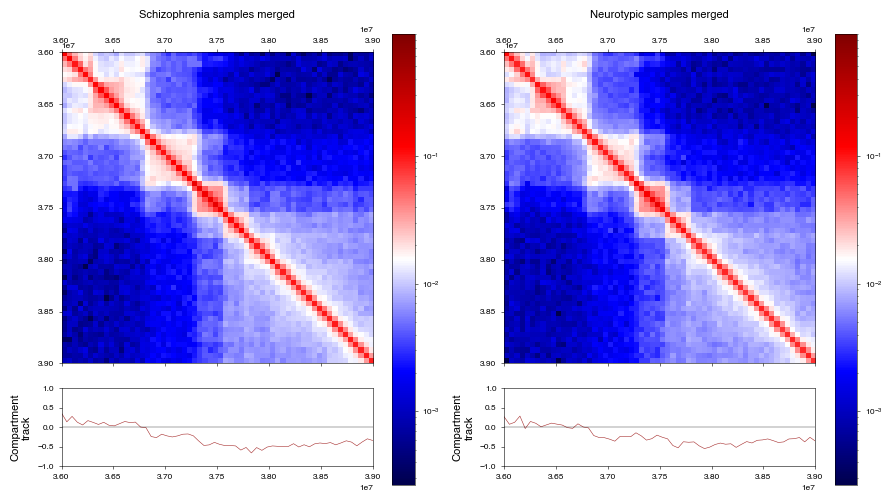

In [27]:
f, axs = plt.subplots(
    figsize=(9, 5),
    ncols=2,
    nrows=1)

cmap_colors = np.array([
    [255, 255, 255, 255],
    [245, 166, 35, 255],
    [208, 2, 27, 255],
    [0, 0, 0, 255]
]) / 255
cmap_nodes = [0, 0.35, 0.6, 1]
cust_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("mycmap", list(zip(cmap_nodes, cmap_colors)))

names = ['SZ_plus_merge', 'HC_plus_merge']

start = '36,000,000'
end = '39,000,000'
chrom = 'chr18'

region = f'{chrom}:{start}-{end}'
eig_df_plot = eig_df.loc[(eig_df['chrom'] == chrom)& (eig_df['start'] >= int(start.replace(',', '')))&(eig_df['end'] <= int(end.replace(',', '')))]
extents = (int(start.replace(',', '')), int(end.replace(',', '')), int(end.replace(',', '')), int(start.replace(',', '')))
norm = matplotlib.colors.LogNorm(vmax=0.9)
norm_div = matplotlib.colors.LogNorm(vmin = 0.1, vmax=10)

chromstarts = []
for i in clrs['HC_plus_merge'].chromnames:
    chromstarts.append(clrs['HC_plus_merge'].extent(i)[0])

color = 'seismic'#cust_cmap

for name in names:
    if 'sz' in name.lower():
        ax = axs[0]
        divider = make_axes_locatable(ax)
        ax1 = divider.append_axes("bottom", size="25%", pad=0.25, sharex=ax)
        weights = clrs[name].bins()[:]['weight'].values
        im = ax.matshow(clrs[name].matrix(balance = True).fetch(region), cmap=color, norm = norm, extent=extents);
        ax1.plot(np.linspace(int(start.replace(',', '')), int(end.replace(',', '')), len(eig_df_plot[f'E1.{name}'].values)), eig_df_plot[f'E1.{name}'].values, color = 'brown')
        ax1.plot([int(start.replace(',', '')),int(end.replace(',', ''))],[0,0],lw=0.25, color = 'black')
        ax1.set_ylabel('Compartment\ntrack')
        ax1.set_ylim([-1, 1])
        ax.set_title('Schizophrenia samples merged')
        plt.colorbar(im, ax=ax)
        
    if 'hc' in name.lower():
        ax = axs[1]
        divider = make_axes_locatable(ax)
        ax1 = divider.append_axes("bottom", size="25%", pad=0.25, sharex=ax)
        weights = clrs[name].bins()[:]['weight'].values
        #print(eig_df_plot[f'E1.{name}'].values)
        im = ax.matshow(clrs[name].matrix(balance = True).fetch(region), cmap=color, norm = norm, extent=extents);
        plt.colorbar(im, ax=ax)# ,fraction=0.046, pad=0.04, label='counts (linear)');
        ax1.plot(np.linspace(int(start.replace(',', '')), int(end.replace(',', '')), len(eig_df_plot[f'E1.{name}'].values)), eig_df_plot[f'E1.{name}'].values, color = 'brown')
        ax1.plot([int(start.replace(',', '')),int(end.replace(',', ''))],[0,0],'k',lw=0.25)
        ax1.set_ylabel('Compartment\ntrack')
        ax1.set_ylim([-1, 1])
        ax.set_title('Neurotypic samples merged')


plt.tight_layout()
#plt.savefig(f"picture_results/compartment_diff_{region}_neu_CELF4_schizo.svg",bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. SZ: Mann-Whitney-Wilcoxon test two-sided, P_val:7.384e-05 U_stat=5.068e+03


/tmp/ipykernel_4188277/3999252421.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box_plot=sns.boxplot(data = expr_celf4, y = 'Pixel', x = '', showfliers=False, palette = groups_colors, showmeans=True,


(<Axes: ylabel='Pixel'>,
 [<statannotations.Annotation.Annotation at 0x7f897cbfcad0>])

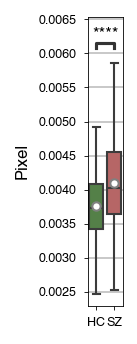

In [28]:
start1 = '37,800,000'
end1 = '39,000,000'
start2= '37,300,000'
end2 = '37,550,000'
chrom = 'chr18'

region1 = f'{chrom}:{start1}-{end1}'
region2 = f'{chrom}:{start2}-{end2}'

hc = pd.DataFrame({'Pixel':clrs['HC_plus_merge'].matrix(balance = True).fetch(region1, region2).reshape(1, -1)[0]})
sz = pd.DataFrame({'Pixel':clrs['SZ_plus_merge'].matrix(balance = True).fetch(region1, region2).reshape(1, -1)[0]})


hc[''] = 'HC'
sz[''] = 'SZ'
expr_celf4 = pd.concat([hc, sz], axis = 0)

groups_colors = {'HC': '#4e893f',
                 'SZ': '#c35959'}

plt.figure(figsize = (0.3, 2.5), dpi=150)


box_plot=sns.boxplot(data = expr_celf4, y = 'Pixel', x = '', showfliers=False, palette = groups_colors, showmeans=True,
                     meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"grey",
                       "markersize":"4", 'linewidth' : 0.1})
plt.grid(0.1, axis = 'y', color = 'grey', alpha = 0.5)

pairs = [('HC', 'SZ')]

annotator = Annotator(box_plot, pairs, data=expr_celf4, y = 'Pixel', x = '')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

#plt.savefig('picture_results/CELF4_pixel_neuron.svg',bbox_inches='tight')
